# Kaelix — verificação numérica dos questionamentos técnicos

Este notebook testa, com simulação controlada, os pontos levantados em
os questionamentos técnicos do projeto.

A lógica é: **construir sinais cuja resposta correta é conhecida de antemão**, passar
esses sinais pela cadeia de medição proposta para o Kaelix e verificar se a resposta
sobrevive. Quando a resposta certa é conhecida, um erro na pipeline não tem como se
esconder atrás de um resultado plausível.

| Item | Pergunta | Seção |
|---|---|---|
| 1 | O MPU6050 consegue ver defeito de rolamento? | [§1](#1) |
| 2 | A cadeia aceleração→velocidade da ISO 10816-3 está correta? | [§2](#2) |
| 6 | Quanto o split errado infla a acurácia? | [§3](#3) |
| 7 | Como `contamination` e a banda afetam o Isolation Forest? | [§4](#4) |

> **Escopo.** Os sinais são sintéticos, com física conhecida. Isso serve para validar a
> *pipeline* e dimensionar efeitos — não substitui MAFAULDA/CWRU nem medição em campo.
> É exatamente a distinção que o item 6 defende: dado sintético verifica a implementação,
> não o desempenho.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import kurtosis

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.titlesize": 10,
})
C_OK, C_DEF, C_REF = "#2E7D9A", "#C1442E", "#5B5B5B"
np.set_printoptions(precision=4, suppress=True)
print("ambiente pronto")

ambiente pronto


## Parâmetros do caso de estudo

Motor de indução de 4 polos a 1750 rpm — regime típico dos equipamentos citados no
projeto. O rolamento é um **SKF 6205**, o mesmo do CWRU, o que permite comparar os
números deste notebook com a literatura.

As frequências características de defeito saem da geometria do rolamento:

$$\mathrm{BPFO} = \frac{N_b}{2} f_r\left(1 - \frac{d}{D}\cos\theta\right)
\qquad
\mathrm{BPFI} = \frac{N_b}{2} f_r\left(1 + \frac{d}{D}\cos\theta\right)$$

onde $f_r$ é a rotação em Hz, $N_b$ o número de esferas, $d$ o diâmetro da esfera,
$D$ o diâmetro primitivo e $\theta$ o ângulo de contato.

In [2]:
RPM = 1750.0
FR = RPM / 60.0                      # rotação em Hz

# SKF 6205 (polegadas) — mesmo rolamento do dataset CWRU
ND, PD, NB, THETA = 0.3126, 1.537, 9, 0.0

def bearing_freqs(fr, nb=NB, nd=ND, pd=PD, theta=THETA):
    r = (nd / pd) * np.cos(theta)
    return {
        "BPFO": nb / 2 * fr * (1 - r),      # pista externa
        "BPFI": nb / 2 * fr * (1 + r),      # pista interna
        "BSF":  pd / (2 * nd) * fr * (1 - r**2),
        "FTF":  fr / 2 * (1 - r),           # gaiola
    }

BF = bearing_freqs(FR)
print(f"rotação f_r = {FR:.2f} Hz ({RPM:.0f} rpm)\n")
for k, v in BF.items():
    print(f"  {k:5s} = {v:7.2f} Hz   ({v/FR:.2f} x f_r)")

rotação f_r = 29.17 Hz (1750 rpm)

  BPFO  =  104.56 Hz   (3.58 x f_r)
  BPFI  =  157.94 Hz   (5.42 x f_r)
  BSF   =   68.74 Hz   (2.36 x f_r)
  FTF   =   11.62 Hz   (0.40 x f_r)


### Simulador de vibração

O sinal reproduz os dois mecanismos que importam para a discussão, com escalas de
frequência muito diferentes:

1. **Desbalanceamento e desalinhamento** — senoides em 1×, 2× e 3× $f_r$, ou seja,
   abaixo de 100 Hz.
2. **Defeito de pista externa** — cada passagem de esfera pelo defeito produz um
   impacto, e cada impacto excita uma **ressonância estrutural** da carcaça, aqui em
   3,5 kHz. O resultado é um trem de impulsos amortecidos, repetido na taxa BPFO
   (105 Hz) mas *cujo conteúdo espectral está em torno de 3,5 kHz*.

Essa separação entre **taxa de repetição** (baixa) e **frequência portadora** (alta) é
o ponto central do item 1, e a razão pela qual "BPFO = 105 Hz cabe em 500 Hz" não
resolve o problema.

O jitter de ±1% na posição dos impulsos modela o escorregamento real das esferas.

In [3]:
def simulate(fs, dur, fr=FR, unbalance=0.5, bearing_defect=0.0,
             f_res=3500.0, decay=800.0, noise=0.05, seed=0):
    """Aceleração simulada em m/s². Retorna (t, x).

    unbalance      : amplitude das componentes 1x/2x/3x f_r
    bearing_defect : amplitude dos impulsos de defeito (0 = rolamento sadio)
    f_res          : ressonância estrutural excitada pelos impactos [Hz]
    """
    rng = np.random.default_rng(seed)
    n = int(fs * dur)
    t = np.arange(n) / fs
    x = np.zeros(n)

    # --- banda baixa: desbalanceamento / desalinhamento / folga
    x += unbalance * np.sin(2 * np.pi * fr * t)
    x += 0.30 * unbalance * np.sin(2 * np.pi * 2 * fr * t + 0.7)
    x += 0.10 * unbalance * np.sin(2 * np.pi * 3 * fr * t + 1.3)

    # --- banda alta: impactos do defeito excitando a ressonância
    if bearing_defect > 0:
        tau = 1.0 / BF["BPFO"]
        for t0 in np.arange(0, dur, tau):
            t0j = t0 + rng.normal(0, 0.01 * tau)      # escorregamento
            k = int(t0j * fs)
            if 0 <= k < n:
                tt = t[k:] - t[k]
                x[k:] += bearing_defect * np.exp(-decay * tt) * np.sin(2 * np.pi * f_res * tt)

    return t, x + rng.normal(0, noise, n)

FS_REF = 20_000.0     # referência: sensor de banda larga
DUR    = 2.0

t_ref, x_def = simulate(FS_REF, DUR, bearing_defect=2.0, seed=0)
_,     x_ok  = simulate(FS_REF, DUR, bearing_defect=0.0, seed=0)
print(f"sinal de referência: {len(x_def)} amostras @ {FS_REF/1000:.0f} kHz  ({DUR:.0f} s)")

sinal de referência: 40000 amostras @ 20 kHz  (2 s)


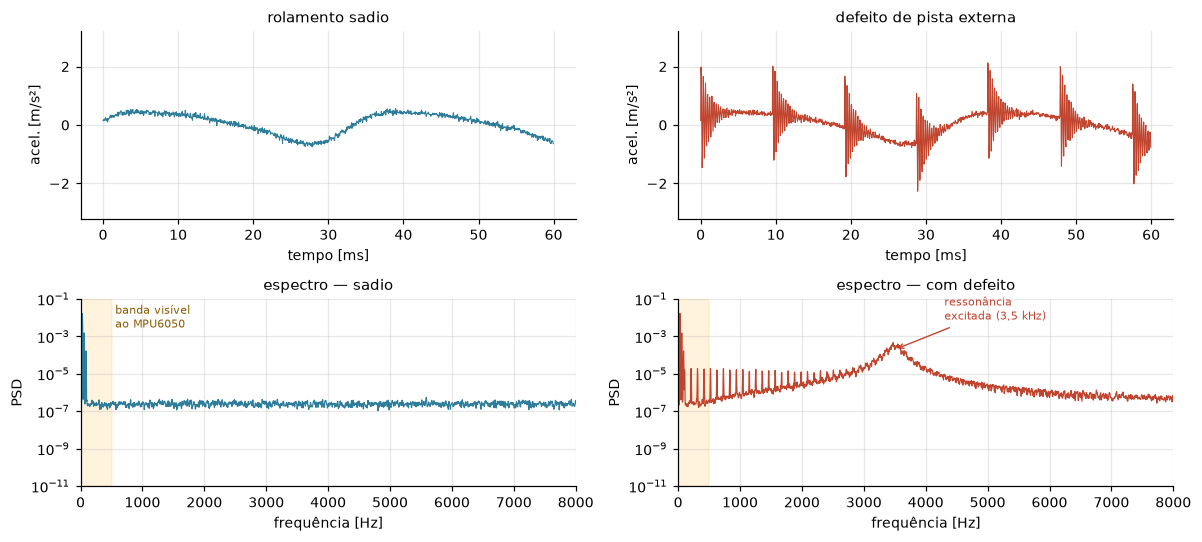

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5))

for ax, x, lab, c in [(axes[0,0], x_ok, "rolamento sadio", C_OK),
                      (axes[0,1], x_def, "defeito de pista externa", C_DEF)]:
    m = t_ref < 0.06
    ax.plot(t_ref[m]*1000, x[m], lw=0.7, color=c)
    ax.set_title(lab); ax.set_xlabel("tempo [ms]"); ax.set_ylabel("acel. [m/s²]")
    ax.set_ylim(-3.2, 3.2)

for ax, x, lab, c in [(axes[1,0], x_ok, "sadio", C_OK), (axes[1,1], x_def, "com defeito", C_DEF)]:
    f, P = signal.welch(x, FS_REF, nperseg=4096)
    ax.semilogy(f, P, lw=0.8, color=c)
    ax.axvspan(0, 500, color="orange", alpha=0.13)
    ax.set_xlim(0, 8000); ax.set_ylim(1e-11, 1e-1)
    ax.set_xlabel("frequência [Hz]"); ax.set_ylabel("PSD")
    ax.set_title(f"espectro — {lab}")
axes[1,0].text(560, 3e-3, "banda visível\nao MPU6050", fontsize=7.5, color="#8a5a00")
axes[1,1].annotate("ressonância\nexcitada (3,5 kHz)", xy=(3500, 2e-4), xytext=(4300, 8e-3),
                   fontsize=7.5, color=C_DEF,
                   arrowprops=dict(arrowstyle="->", color=C_DEF, lw=0.9))
plt.tight_layout()
plt.show()

Os dois painéis de baixo mostram a assimetria que define o problema: no sinal com
defeito surge um lobo de energia em torno de 3,5 kHz que não existe no sinal sadio —
e ele está **inteiramente fora da faixa laranja**, que é tudo o que o MPU6050 alcança.

<a id="1"></a>
## 1. O limite de banda do MPU6050

O MPU6050 tem ODR máximo de 1 kHz no acelerômetro, logo Nyquist em 500 Hz. A questão
é o que se perde.

Vamos comparar três cadeias de aquisição do mesmo sinal físico:

| Cadeia | Descrição |
|---|---|
| **A. Referência** | 20 kHz, banda larga — o que um ADXL1002 entregaria |
| **B. MPU6050 correto** | decimação para 1 kHz *com* filtro antialiasing |
| **C. MPU6050 ingênuo** | leitura direta a 1 kHz *sem* antialiasing |

A cadeia C é o erro fácil de cometer: basta ler o registrador a 1 kHz sem configurar o
DLPF adequadamente.

In [5]:
FS_MPU = 1000.0
DEC = int(FS_REF / FS_MPU)

# B — decimação correta (filtro FIR antialiasing embutido)
mpu_def = signal.decimate(x_def, DEC, ftype="fir", zero_phase=True)
mpu_ok  = signal.decimate(x_ok,  DEC, ftype="fir", zero_phase=True)

# C — subamostragem crua, sem antialiasing
alias_def = x_def[::DEC]
alias_ok  = x_ok[::DEC]

crest = lambda x: np.max(np.abs(x)) / np.sqrt(np.mean(x**2))

# Fidali et al. (Sensors, 2024) apontam pico e pico-a-pico de aceleração como os
# parâmetros mais sensíveis a falha de fadiga — mais que a velocidade RMS. Testamos
# se essas features resistem melhor à limitação de banda que curtose e fator de crista.
FEATURES = {
    "curtose":         lambda x: kurtosis(x, fisher=False),
    "fator de crista": crest,
    "pico":            lambda x: np.max(np.abs(x)),
    "pico-a-pico":     lambda x: np.ptp(x),
}

CADEIAS = [("A. referência 20 kHz", x_ok, x_def),
           ("B. MPU6050 c/ antialias", mpu_ok, mpu_def),
           ("C. MPU6050 s/ antialias", alias_ok, alias_def)]

print(f"{'cadeia':<26} {'feature':<16} {'sadio':>8} {'defeito':>9} {'razão':>8}")
print("-" * 72)
for nome, a, b in CADEIAS:
    for fnome, fn in FEATURES.items():
        va, vb = fn(a), fn(b)
        marca = "  <-- separa" if vb/va > 1.5 else ""
        print(f"{nome:<26} {fnome:<16} {va:>8.2f} {vb:>9.2f} {vb/va:>8.2f}{marca}")
    print()

cadeia                     feature             sadio   defeito    razão
------------------------------------------------------------------------
A. referência 20 kHz       curtose              1.80      4.64     2.57  <-- separa
A. referência 20 kHz       fator de crista      2.17      4.57     2.11  <-- separa
A. referência 20 kHz       pico                 0.81      2.38     2.93  <-- separa
A. referência 20 kHz       pico-a-pico          1.41      4.63     3.28  <-- separa

B. MPU6050 c/ antialias    curtose              1.76      1.77     1.01
B. MPU6050 c/ antialias    fator de crista      1.83      1.83     1.00
B. MPU6050 c/ antialias    pico                 0.68      0.68     1.01
B. MPU6050 c/ antialias    pico-a-pico          1.15      1.23     1.07

C. MPU6050 s/ antialias    curtose              1.82      4.55     2.49  <-- separa
C. MPU6050 s/ antialias    fator de crista      2.14      4.24     1.98  <-- separa
C. MPU6050 s/ antialias    pico                 0.80      2.1

Leitura da tabela:

- **Cadeia A** separa bem em todas as quatro descritores. A curtose mede o peso das caudas
  da distribuição, e impactos produzem exatamente caudas pesadas; pico e pico-a-pico
  respondem à amplitude dos próprios impactos.
- **Cadeia B** perde a separação em **todas elas**, com razões defeito/sadio caindo para
  ~1,0. O filtro antialiasing, fazendo o que deve fazer, remove os impulsos junto com a
  banda alta.
- **Cadeia C** aparenta funcionar — curtose ~4,5, próxima da referência. Esse valor, porém, é artefato,
  como a próxima célula demonstra.

O comportamento de pico e pico-a-pico contraria a expectativa inicial. Fidali et al. (Sensors, 2024)
identificam esses dois como os parâmetros **mais sensíveis** a falhas de fadiga em
rolamento, acima da velocidade RMS. Esperava-se, portanto, maior resistência à
limitação de banda — mas eles colapsam junto com os demais (razão de 2,93 e 3,28 na
referência, contra 1,01 e 1,07 na banda do MPU6050). **A recomendação da literatura
sobre qual descritor usar não resgata um sensor de banda insuficiente**: o problema está
na aquisição, não na escolha de descritor.

In [6]:
# Onde a energia de 3,5 kHz reaparece quando não há antialiasing?
print("dobramento por aliasing (fs = 1000 Hz):\n")
for fres in [3000, 3300, 3500, 4200, 5100]:
    a = fres % FS_MPU
    fold = a if a <= FS_MPU/2 else FS_MPU - a
    print(f"  ressonância real em {fres:5.0f} Hz  ->  aparece em {fold:5.0f} Hz")

print("\nO conteúdo é preservado em energia, mas realocado para uma frequência falsa.")
print("A curtose sobrevive porque é uma estatística de amplitude e ignora frequência.")
print("Qualquer diagnóstico que dependa de ONDE está a energia fica errado.")

dobramento por aliasing (fs = 1000 Hz):

  ressonância real em  3000 Hz  ->  aparece em     0 Hz
  ressonância real em  3300 Hz  ->  aparece em   300 Hz
  ressonância real em  3500 Hz  ->  aparece em   500 Hz
  ressonância real em  4200 Hz  ->  aparece em   200 Hz
  ressonância real em  5100 Hz  ->  aparece em   100 Hz

O conteúdo é preservado em energia, mas realocado para uma frequência falsa.
A curtose sobrevive porque é uma estatística de amplitude e ignora frequência.
Qualquer diagnóstico que dependa de ONDE está a energia fica errado.


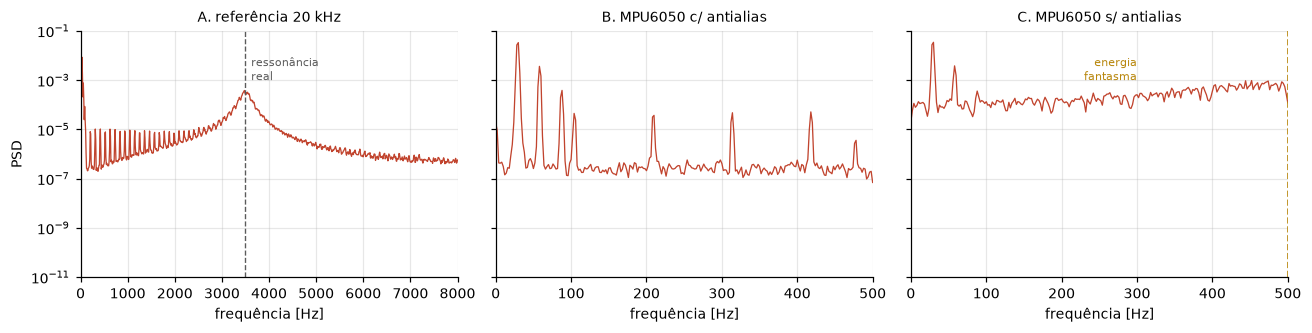

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.1), sharey=True)
for ax, (x, fs, lab) in zip(axes, [
        (x_def, FS_REF, "A. referência 20 kHz"),
        (mpu_def, FS_MPU, "B. MPU6050 c/ antialias"),
        (alias_def, FS_MPU, "C. MPU6050 s/ antialias")]):
    f, P = signal.welch(x, fs, nperseg=min(2048, len(x)//4))
    ax.semilogy(f, P, lw=0.85, color=C_DEF)
    ax.set_xlim(0, 8000 if fs > 5000 else 500)
    ax.set_title(lab, fontsize=9); ax.set_xlabel("frequência [Hz]")
axes[0].axvline(3500, color=C_REF, ls="--", lw=0.9)
axes[0].text(3620, 1e-3, "ressonância\nreal", fontsize=7.5, color=C_REF)
axes[2].axvline(500, color="#B8860B", ls="--", lw=1.1)
axes[2].text(300, 1e-3, "energia\nfantasma", fontsize=7.5, color="#B8860B", ha="right")
axes[0].set_ylabel("PSD"); axes[0].set_ylim(1e-11, 1e-1)
plt.tight_layout(); plt.show()

### Mas a detecção é realmente impossível?

Vale checar a versão mais forte do argumento antes de aceitá-la. Como BPFO = 105 Hz
está *dentro* da banda do MPU6050, resta energia detectável ali? A comparação justa é
entre o método correto para rolamento (**análise de envelope** sobre a banda de
ressonância, disponível só a 20 kHz) e o que sobra na banda estreita.

In [8]:
def envelope_spectrum(x, fs, band=(2000, 6000)):
    """Demodulação de amplitude na banda de ressonância — método padrão para rolamento."""
    sos = signal.butter(4, band, "bandpass", fs=fs, output="sos")
    env = np.abs(signal.hilbert(signal.sosfiltfilt(sos, x)))
    env -= env.mean()
    n = len(env)
    E = np.abs(np.fft.rfft(env * signal.windows.hann(n))) / n * 2
    return np.fft.rfftfreq(n, 1/fs), E

def peak_at(f, S, f0, tol=3.0):
    m = np.abs(f - f0) <= tol
    return S[m].max()

# A: envelope na banda de ressonância (20 kHz)
fe_d, Ee_d = envelope_spectrum(x_def, FS_REF)
fe_o, Ee_o = envelope_spectrum(x_ok,  FS_REF)
razao_env = peak_at(fe_d, Ee_d, BF["BPFO"]) / peak_at(fe_o, Ee_o, BF["BPFO"])

# B: espectro direto na banda do MPU6050
def spec(x, fs):
    n = len(x)
    return np.fft.rfftfreq(n, 1/fs), np.abs(np.fft.rfft(x*signal.windows.hann(n)))/n*2
fm_d, Sm_d = spec(mpu_def, FS_MPU)
fm_o, Sm_o = spec(mpu_ok,  FS_MPU)
razao_mpu = peak_at(fm_d, Sm_d, BF["BPFO"]) / peak_at(fm_o, Sm_o, BF["BPFO"])

print(f"contraste defeito/sadio no pico BPFO ({BF['BPFO']:.0f} Hz):\n")
print(f"  A. envelope na ressonância (20 kHz) : {razao_env:8.1f} x")
print(f"  B. espectro direto (MPU6050, 1 kHz) : {razao_mpu:8.1f} x")
print(f"\n  perda de contraste: {razao_env/razao_mpu:.0f} x")

contraste defeito/sadio no pico BPFO (105 Hz):

  A. envelope na ressonância (20 kHz) :    413.3 x
  B. espectro direto (MPU6050, 1 kHz) :     19.6 x

  perda de contraste: 21 x


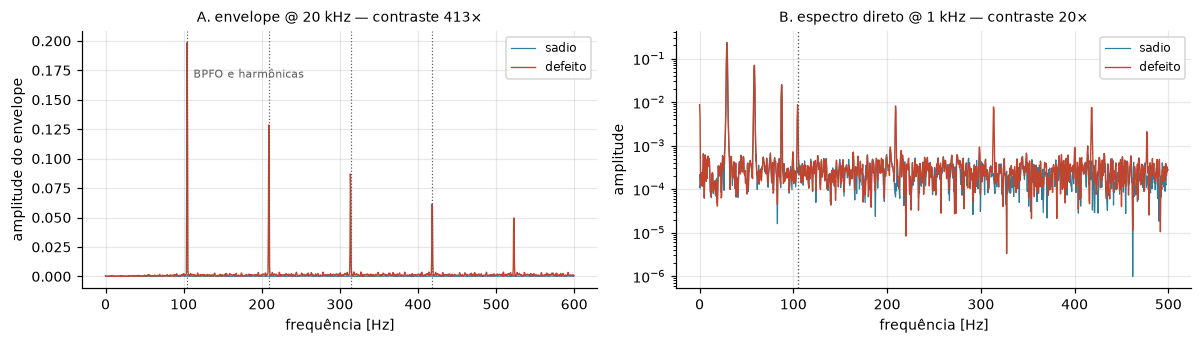

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
ax = axes[0]
m = fe_d < 600
ax.plot(fe_o[m], Ee_o[m], lw=0.8, color=C_OK, label="sadio")
ax.plot(fe_d[m], Ee_d[m], lw=0.9, color=C_DEF, label="defeito")
for i in range(1, 5):
    ax.axvline(i*BF["BPFO"], color=C_REF, ls=":", lw=0.8)
ax.text(BF["BPFO"]+8, Ee_d[m].max()*0.85, "BPFO e harmônicas", fontsize=7.5, color=C_REF)
ax.set_title(f"A. envelope @ 20 kHz — contraste {razao_env:.0f}×", fontsize=9)
ax.set_xlabel("frequência [Hz]"); ax.set_ylabel("amplitude do envelope"); ax.legend(fontsize=8)

ax = axes[1]
m2 = fm_d < 500
ax.semilogy(fm_o[m2], Sm_o[m2], lw=0.8, color=C_OK, label="sadio")
ax.semilogy(fm_d[m2], Sm_d[m2], lw=0.9, color=C_DEF, label="defeito")
ax.axvline(BF["BPFO"], color=C_REF, ls=":", lw=0.9)
ax.set_title(f"B. espectro direto @ 1 kHz — contraste {razao_mpu:.0f}×", fontsize=9)
ax.set_xlabel("frequência [Hz]"); ax.set_ylabel("amplitude"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Conclusão do item 1

O resultado é mais matizado do que "o MPU6050 não detecta rolamento", e vale registrar
a versão precisa:

- Com antialiasing correto, **ainda sobra sinal em BPFO** — cerca de 20× de contraste
  no espectro direto. Detecção não é impossível.
- Mas o método de referência entrega ~413× de contraste. A margem cai por um fator
  próximo de 21, e é essa margem que acomoda variação de carga, temperatura, montagem e
  ruído elétrico em campo. Em bancada 20× funciona; em planta, com o motor mudando de
  regime, essa margem some.
- **A curtose e o fator de crista deixam de servir** (1,76 vs 1,77) — e são justamente
  duas das quatro descritores previstas no projeto.
- A cadeia C (sem antialiasing) produz artefato de interpretação: produz curtose alta e dá impressão de
  funcionar, mas a frequência observada é artefato. Se o DLPF do MPU6050 não estiver
  configurado, é isso que o Kaelix vai medir.

**Recomendação.** Para desbalanceamento e desalinhamento, o MPU6050 é suficiente e a
detecção é robusta. Para rolamento, a margem é estreita demais para ambiente industrial —
e, se ficar com o MPU6050, é obrigatório configurar o DLPF e documentar que as descritores
de impacto não são confiáveis.

<a id="2"></a>
## 2. Aceleração → velocidade: a cadeia exigida pela ISO 10816-3

A ISO 10816-3 define as zonas A–D em **velocidade RMS (mm/s)** na banda de 10 a 1000 Hz.
O MPU6050 mede **aceleração (m/s²)**. Aplicar limiares de mm/s a valores de m/s² é um
erro de unidade que produz rotulagem sem significado físico.

O teste usa uma senoide, cuja integral é conhecida analiticamente. Para
$a(t) = A\sin(2\pi f_0 t)$:

$$v(t) = -\frac{A}{2\pi f_0}\cos(2\pi f_0 t)
\qquad\Longrightarrow\qquad
v_{\text{RMS}} = \frac{A/\sqrt{2}}{2\pi f_0}$$

Com $A = 3{,}0$ m/s² e $f_0 = 50$ Hz, o valor exato é conhecido — qualquer método que
não chegue nele está errado.

In [10]:
FS_V, DUR_V = 5000.0, 4.0
A_AMP, F0 = 3.0, 50.0

tv = np.arange(int(FS_V*DUR_V)) / FS_V
a_test = A_AMP * np.sin(2*np.pi*F0*tv)

V_EXATO = (A_AMP/np.sqrt(2)) / (2*np.pi*F0) * 1000.0   # mm/s RMS
print(f"a(t) = {A_AMP} sin(2π·{F0:.0f}·t)  m/s²")
print(f"aceleração RMS = {np.sqrt(np.mean(a_test**2)):.4f} m/s²")
print(f"velocidade RMS = {V_EXATO:.4f} mm/s   <-- valor analítico exato")

a(t) = 3.0 sin(2π·50·t)  m/s²
aceleração RMS = 2.1213 m/s²
velocidade RMS = 6.7524 mm/s   <-- valor analítico exato


In [11]:
def vel_tempo_sem_hp(a, fs):
    """Integração no tempo, sem tratamento — o jeito ingênuo."""
    return np.cumsum(a) / fs * 1000.0

def vel_tempo_com_hp(a, fs, hp=10.0):
    """Integração no tempo com passa-alta antes, para remover DC."""
    sos = signal.butter(4, hp, "hp", fs=fs, output="sos")
    return np.cumsum(signal.sosfiltfilt(sos, a)) / fs * 1000.0

def vel_freq(a, fs, f_lo=10.0, f_hi=1000.0):
    """Integração no domínio da frequência com banda ISO 10816-3.

    V(f) = A(f) / (j·2πf), aplicada só em 10–1000 Hz.
    Compensa o ganho RMS da janela de Hann.
    """
    n = len(a)
    w = signal.windows.hann(n)
    A = np.fft.rfft(a * w)
    f = np.fft.rfftfreq(n, 1/fs)
    V = np.zeros_like(A)
    m = (f >= f_lo) & (f <= f_hi)
    V[m] = A[m] / (2j * np.pi * f[m])
    return np.fft.irfft(V, n) / np.sqrt(np.mean(w**2)) * 1000.0

rms = lambda x: np.sqrt(np.mean(x**2))

# offset de apenas 0,02 m/s² — bias típico, dentro da spec do MPU6050
a_bias = a_test + 0.02

resultados = [
    ("integração no tempo, sem passa-alta", rms(vel_tempo_sem_hp(a_test, FS_V))),
    ("integração no tempo, com passa-alta", rms(vel_tempo_com_hp(a_test, FS_V))),
    ("integração na frequência (banda ISO)", rms(vel_freq(a_test, FS_V))),
    ("na frequência, com bias de 0,02 m/s²", rms(vel_freq(a_bias, FS_V))),
    ("no tempo sem HP, com bias 0,02 m/s²", rms(vel_tempo_sem_hp(a_bias, FS_V))),
]
print(f"valor exato: {V_EXATO:.4f} mm/s\n")
print(f"{'método':<40} {'RMS [mm/s]':>12} {'erro':>12}")
print("-"*66)
for nome, v in resultados:
    err = (v - V_EXATO) / V_EXATO * 100
    flag = "  ok" if abs(err) < 1 else ("  <-- ERRADO" if abs(err) > 20 else "  <-- impreciso")
    print(f"{nome:<40} {v:>12.4f} {err:>11.1f}%{flag}")

valor exato: 6.7524 mm/s

método                                     RMS [mm/s]         erro
------------------------------------------------------------------
integração no tempo, sem passa-alta           11.6935        73.2%  <-- ERRADO
integração no tempo, com passa-alta           17.3113       156.4%  <-- ERRADO
integração na frequência (banda ISO)           6.7525         0.0%  ok
na frequência, com bias de 0,02 m/s²           6.7525         0.0%  ok
no tempo sem HP, com bias 0,02 m/s²           55.0814       715.7%  <-- ERRADO


Três conclusões saem direto da tabela:

1. **Integração na frequência acerta** — erro de 0,0%, e continua exata mesmo com o
   bias de 0,02 m/s² aplicado, porque o bin de DC fica fora da banda de 10–1000 Hz e é
   descartado pela própria máscara da norma. É o método a usar, e o custo computacional
   é praticamente nulo no Kaelix, já que a FFT já é calculada para as descritores.
2. **Integração no tempo erra mesmo com passa-alta** — 156% neste teste, pior que os
   73% sem filtro algum. O passa-alta remove o DC, mas o `cumsum` ainda acumula o
   transiente de borda do filtro, e esse offset residual domina o RMS. Corrigir exigiria
   descartar as bordas e aplicar detrend — trabalho que a via da frequência dispensa.
3. **Sem passa-alta, um bias de 0,02 m/s² é catastrófico** — erro de 716%. Esse offset
   é pequeno, dentro da especificação de qualquer MPU6050, e ainda assim a rampa de
   integração leva o RMS a 55 mm/s, quando o valor correto é 6,75. Um sinal que está na
   zona A da norma seria classificado muito além da zona D.

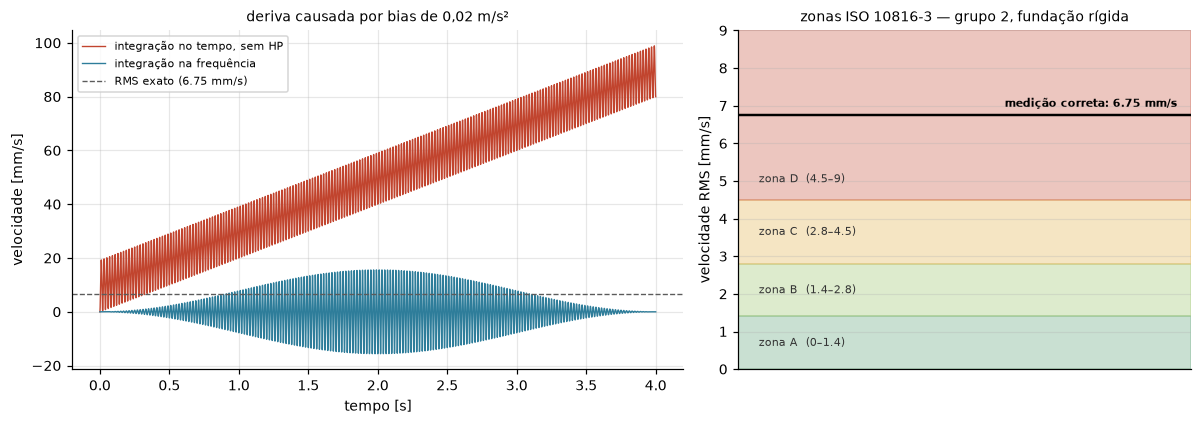

In [12]:
v_bad  = vel_tempo_sem_hp(a_bias, FS_V)
v_good = vel_freq(a_bias, FS_V)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.940), gridspec_kw={"width_ratios":[1.35,1]})
ax = axes[0]
ax.plot(tv, v_bad, lw=0.9, color=C_DEF, label="integração no tempo, sem HP")
ax.plot(tv, v_good, lw=0.9, color=C_OK, label="integração na frequência")
ax.axhline(V_EXATO, color=C_REF, ls="--", lw=0.9, label=f"RMS exato ({V_EXATO:.2f} mm/s)")
ax.set_xlabel("tempo [s]"); ax.set_ylabel("velocidade [mm/s]")
ax.set_title("deriva causada por bias de 0,02 m/s²", fontsize=9)
ax.legend(fontsize=7.5, loc="upper left")

# Contexto: as zonas ISO para máquina do grupo 1 em fundação rígida
ax = axes[1]
zonas = [("A", 0, 1.4, "#4C9A6A"), ("B", 1.4, 2.8, "#8FBF5A"),
         ("C", 2.8, 4.5, "#E0A93B"), ("D", 4.5, 9.0, "#C1442E")]
for lab, lo, hi, c in zonas:
    ax.axhspan(lo, hi, color=c, alpha=0.30)
    yl = (lo+hi)/2 if lab != "D" else lo + 0.55      # evita a linha da medição
    ax.text(0.045, yl, f"zona {lab}  ({lo:g}–{hi:g})", fontsize=7.5,
            va="center", color="#333")
ax.axhline(V_EXATO, color="black", lw=1.6)
ax.text(0.97, V_EXATO+0.22, f"medição correta: {V_EXATO:.2f} mm/s",
        fontsize=7.5, ha="right", weight="bold")
ax.set_ylim(0, 9); ax.set_xlim(0, 1); ax.set_xticks([])
ax.set_ylabel("velocidade RMS [mm/s]")
ax.set_title("zonas ISO 10816-3 — grupo 2, fundação rígida", fontsize=9)
plt.tight_layout(); plt.show()

A modulação suave do traço azul é a janela de Hann usada na integração espectral; ela
não afeta o RMS, que é compensado pelo fator de ganho da janela.

> **Atenção aos limiares do painel direito.** Os valores 1,4 / 2,8 / 4,5 mm/s
> correspondem a *uma* classe de máquina (grupo 2, fundação rígida) e estão aqui apenas
> para dar escala visual. A ISO 10816-3 define limiares distintos conforme potência,
> tipo de fundação e grupo — que é exatamente o **item 3** dos questionamentos, e
> continua pendente de levantamento na Skala. Nenhum número deste notebook deve ser
> copiado para o firmware sem confrontar o texto oficial da norma.

In [13]:
# Verificação extra: a cadeia funciona em sinal multi-componente?
# Três senoides, cada uma com contribuição de velocidade conhecida.
comp = [(2.0, 30.0), (1.0, 120.0), (0.5, 400.0)]
a_multi = sum(A*np.sin(2*np.pi*f*tv + i) for i, (A, f) in enumerate(comp))

# Parseval: contribuições de velocidade somam em quadratura
v_teor = np.sqrt(sum(((A/np.sqrt(2))/(2*np.pi*f)*1000.0)**2 for A, f in comp))
v_calc = rms(vel_freq(a_multi, FS_V))

print("sinal com 3 componentes:")
for A, f in comp:
    print(f"   {A:.1f} m/s² @ {f:5.0f} Hz  ->  {(A/np.sqrt(2))/(2*np.pi*f)*1000:6.3f} mm/s")
print(f"\n  teórico (soma em quadratura): {v_teor:.4f} mm/s")
print(f"  calculado pela pipeline:      {v_calc:.4f} mm/s")
print(f"  erro: {(v_calc-v_teor)/v_teor*100:+.3f}%")

sinal com 3 componentes:
   2.0 m/s² @    30 Hz  ->   7.503 mm/s
   1.0 m/s² @   120 Hz  ->   0.938 mm/s
   0.5 m/s² @   400 Hz  ->   0.141 mm/s

  teórico (soma em quadratura): 7.5623 mm/s
  calculado pela pipeline:      7.5626 mm/s
  erro: +0.003%


### Conclusão do item 2

A cadeia correta para o firmware do Kaelix é:

1. remover o bias do acelerômetro (média ou passa-alta em 10 Hz);
2. aplicar a FFT que já é calculada para as descritores;
3. dividir cada bin por $j2\pi f$, zerando fora de 10–1000 Hz;
4. calcular o RMS — no domínio da frequência, por Parseval, sem precisar da IFFT;
5. só então comparar com os limiares da norma para a classe correta da máquina.

O erro de 0,003% no teste multi-componente confirma a implementação em sinal realista,
com várias frequências somadas. Vale notar que o passo 3 depende do item 1: com Nyquist em 500 Hz, o Kaelix cobre
apenas metade da banda de 10–1000 Hz que a norma exige. **A conformidade plena com a
ISO 10816-3 já não é possível com o MPU6050** — um argumento adicional, independente
do de rolamento, para revisar o sensor.

<a id="3"></a>
## 3. Vazamento de dados: por que o CWRU produz 99%

O mecanismo é o seguinte. Janelas consecutivas do mesmo arquivo compartilham a
assinatura daquela montagem — nível de ruído, ganho do sensor, condição de aperto. Se essas janelas forem
divididas aleatoriamente entre treino e teste, o modelo pode identificar *o ensaio* em
vez de *a falha*, e mesmo assim acertar o rótulo.

Para reproduzir isso de forma realista, a simulação usa:

- **defeito incipiente** (amplitude 0,25 em vez de 2,0) — o caso que importa em
  manutenção preditiva, quando ainda há tempo de agir;
- **assinatura de ensaio forte** — ganho e ruído sorteados por ensaio, como montagens
  diferentes;
- **poucos ensaios** (5 por classe), como no CWRU, onde há tipicamente um arquivo por
  condição;
- **banda do MPU6050**, para medir o cenário real do Kaelix.

In [14]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

def extrair_features(x, fs):
    """As features previstas no projeto + energia por banda."""
    r = np.sqrt(np.mean(x**2))
    mabs = np.mean(np.abs(x))
    f = np.fft.rfftfreq(len(x), 1/fs)
    P = np.abs(np.fft.rfft(x*signal.windows.hann(len(x))))**2
    bandas = [(0,100),(100,500)] if fs <= 1100 else [(0,100),(100,500),(500,2000),(2000,6000)]
    e = [P[(f>=a)&(f<b)].sum() for a,b in bandas]
    tot = sum(e) + 1e-12
    return np.array([r, kurtosis(x, fisher=False), np.max(np.abs(x))/r,
                     mabs, r/mabs] + [v/tot for v in e])

def janelas(x, fs, win=0.2, hop=0.1):
    n, h = int(win*fs), int(hop*fs)
    return [x[i:i+n] for i in range(0, len(x)-n, h)]

N_ENSAIOS = 5

def gerar_ensaios(defeito, seed0):
    """Cada ensaio tem ganho e ruído próprios: a 'assinatura de montagem'."""
    out = []
    for i in range(N_ENSAIOS):
        rng = np.random.default_rng(seed0 + i*7)
        ganho = rng.uniform(0.6, 1.6)
        _, x = simulate(FS_REF, 3.0,
                        unbalance=rng.uniform(0.3,0.7)*ganho,
                        bearing_defect=defeito*ganho,
                        noise=rng.uniform(0.03,0.12)*ganho,
                        seed=seed0*100+i)
        out.append(x)
    return out

sadios   = gerar_ensaios(0.00, 1)
defeitos = gerar_ensaios(0.25, 60)      # defeito INCIPIENTE

X, y, ensaio = [], [], []
for r, x in enumerate(sadios + defeitos):
    xm = signal.decimate(x, DEC, ftype="fir", zero_phase=True)   # banda do MPU6050
    for w in janelas(xm, FS_MPU):
        X.append(extrair_features(w, FS_MPU))
        y.append(0 if r < N_ENSAIOS else 1)
        ensaio.append(r)
X, y, ensaio = np.array(X), np.array(y), np.array(ensaio)
print(f"{X.shape[0]} janelas, {X.shape[1]} features, {len(set(ensaio))} ensaios")
print(f"classes: {np.bincount(y)}  (0=sadio, 1=defeito)")

280 janelas, 7 features, 10 ensaios
classes: [140 140]  (0=sadio, 1=defeito)


In [15]:
# --- Split ERRADO: aleatório por janela ---
acc_vazamento = []
for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3,
                                          random_state=seed, stratify=y)
    clf = RandomForestClassifier(n_estimators=150, random_state=0).fit(Xtr, ytr)
    acc_vazamento.append(clf.score(Xte, yte))

# --- Split CORRETO: por ensaio (nenhum ensaio aparece nos dois lados) ---
acc_grupo = []
for tr, te in GroupKFold(n_splits=5).split(X, y, groups=ensaio):
    if len(set(y[te])) < 2:
        continue
    clf = RandomForestClassifier(n_estimators=150, random_state=0).fit(X[tr], y[tr])
    acc_grupo.append(clf.score(X[te], y[te]))

base = max(y.mean(), 1 - y.mean())
print(f"split aleatório por janela  : {np.mean(acc_vazamento):.3f} ± {np.std(acc_vazamento):.3f}")
print(f"split por ensaio (GroupKFold): {np.mean(acc_grupo):.3f} ± {np.std(acc_grupo):.3f}")
print(f"chute na classe majoritária : {base:.3f}")
print(f"\nacurácia por fold no split correto: {[round(a,3) for a in acc_grupo]}")
print(f"\ninflação aparente: +{(np.mean(acc_vazamento)-np.mean(acc_grupo))*100:.1f} pontos percentuais")

split aleatório por janela  : 0.990 ± 0.010
split por ensaio (GroupKFold): 0.632 ± 0.192
chute na classe majoritária : 0.500

acurácia por fold no split correto: [0.5, 0.643, 1.0, 0.518, 0.5]

inflação aparente: +35.8 pontos percentuais


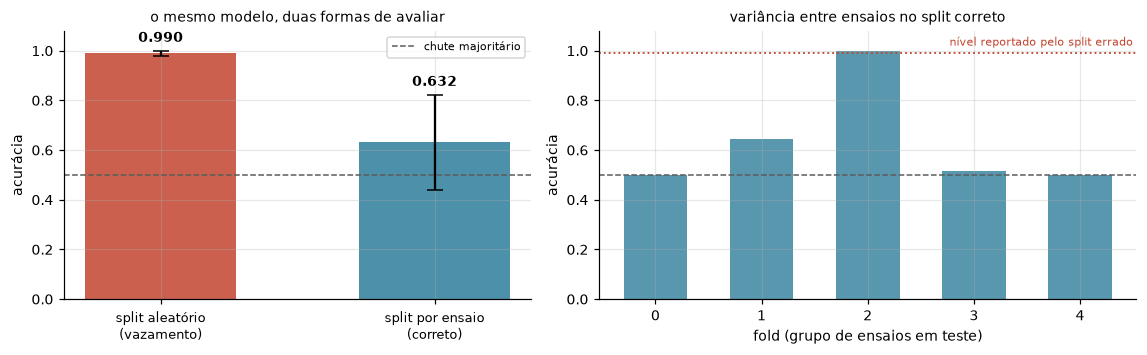

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3), gridspec_kw={"width_ratios":[1,1.15]})
ax = axes[0]
ax.bar([0,1], [np.mean(acc_vazamento), np.mean(acc_grupo)],
       yerr=[np.std(acc_vazamento), np.std(acc_grupo)],
       color=[C_DEF, C_OK], width=0.55, capsize=5, alpha=0.85)
ax.axhline(base, color=C_REF, ls="--", lw=1, label="chute majoritário")
ax.set_xticks([0,1]); ax.set_xticklabels(["split aleatório\n(vazamento)", "split por ensaio\n(correto)"], fontsize=8.5)
ax.set_ylabel("acurácia"); ax.set_ylim(0, 1.08); ax.legend(fontsize=7.5)
ax.set_title("o mesmo modelo, duas formas de avaliar", fontsize=9)
for i, (v, s) in enumerate([(np.mean(acc_vazamento), np.std(acc_vazamento)),
                            (np.mean(acc_grupo), np.std(acc_grupo))]):
    ax.text(i, v+s+0.035, f"{v:.3f}", ha="center", fontsize=9, weight="bold")

ax = axes[1]
ax.bar(range(len(acc_grupo)), acc_grupo, color=C_OK, alpha=0.8, width=0.6)
ax.axhline(base, color=C_REF, ls="--", lw=1)
ax.axhline(np.mean(acc_vazamento), color=C_DEF, ls=":", lw=1.2)
ax.text(len(acc_grupo)-0.5, np.mean(acc_vazamento)+0.03, "nível reportado pelo split errado",
        fontsize=7, color=C_DEF, ha="right")
ax.set_xlabel("fold (grupo de ensaios em teste)"); ax.set_ylabel("acurácia")
ax.set_ylim(0, 1.08); ax.set_title("variância entre ensaios no split correto", fontsize=9)
plt.tight_layout(); plt.show()

### Conclusão do item 6

O mesmo modelo, os mesmos dados, as mesmas descritores: **99,0%** com split aleatório e
**63,2% ± 19,2%** com split por ensaio. A diferença de ~36 pontos é pura ilusão de
avaliação.

O painel direito é o mais informativo: três dos cinco folds ficam em torno de 0,5,
ou seja, no nível do chute — enquanto um chega a 1,0, o que isoladamente daria a
impressão oposta. O modelo não generaliza para ensaios que nunca viu — e o desvio-padrão elevado
evidencia isso, enquanto a média única do split errado esconde tudo.

**Regras para a validação do Kaelix:**

- dividir sempre por **ensaio ou arquivo**, com `GroupKFold` ou `GroupShuffleSplit`;
- reportar **média e desvio entre folds** — desvio alto significa que faltam ensaios,
  não que o modelo é ruim;
- desconfiar de qualquer acurácia acima de ~95% no CWRU: quase sempre é vazamento;
- tratar resultado em dado sintético como teste de pipeline, jamais como desempenho.

<a id="4"></a>
## 4. Isolation Forest: `contamination` e o efeito da banda

Dois pontos práticos sobre o modelo escolhido. A escolha em si é adequada — treinar só
com dados normais é o cenário realista, já que uma planta em operação não fornece falhas
sob demanda.

### 4.1 `contamination` define o limiar, não a qualidade

O parâmetro `contamination` informa ao modelo qual fração do conjunto de treino é
anômala. Se o treino contém apenas dados normais, esse valor deveria ser próximo de
zero — mas o default do scikit-learn é `"auto"`, que **não** assume isso.

In [17]:
# Cenário do Kaelix: treina só com dados de operação normal.
# Aqui o defeito é bem visível, para isolar o efeito do parâmetro.
sadios_c   = gerar_ensaios(0.0, 200)
defeitos_c = gerar_ensaios(2.0, 300)

Xc, yc = [], []
for r, x in enumerate(sadios_c + defeitos_c):
    for w in janelas(x, FS_REF):
        Xc.append(extrair_features(w, FS_REF))
        yc.append(0 if r < N_ENSAIOS else 1)
Xc, yc = np.array(Xc), np.array(yc)

sc = StandardScaler().fit(Xc[yc==0])          # normaliza só com dados normais
Xn = sc.transform(Xc)

print(f"{'contamination':>14} {'falso alarme':>14} {'detecção':>10}")
print("-"*42)
for cont in [0.5, 0.2, 0.1, 0.01, "auto"]:
    iso = IsolationForest(contamination=cont, n_estimators=200,
                          random_state=0).fit(Xn[yc==0])
    fa = (iso.predict(Xn[yc==0]) == -1).mean()
    det = (iso.predict(Xn[yc==1]) == -1).mean()
    marca = "   <-- default" if cont == "auto" else ""
    print(f"{str(cont):>14} {fa:>13.1%} {det:>10.1%}{marca}")

 contamination   falso alarme   detecção
------------------------------------------
           0.5         50.0%     100.0%


           0.2         20.0%     100.0%
           0.1         10.0%     100.0%


          0.01          1.4%     100.0%
          auto         42.1%     100.0%   <-- default


Com `contamination="auto"`, **42% dos dados normais são marcados como anomalia**. Num
dispositivo que envia alerta de manutenção, isso significa que mais de um terço dos
alertas seria falso — e o operador para de confiar no sistema em poucos dias.

O parâmetro não muda a *qualidade* do detector, apenas onde o limiar é colocado. O que
mede a qualidade, independentemente do limiar, é o AUC.

In [18]:
iso = IsolationForest(contamination="auto", n_estimators=200, random_state=0).fit(Xn[yc==0])
scores = -iso.score_samples(Xn)
print(f"AUC (independe do limiar) = {roc_auc_score(yc, scores):.3f}")
print("\nO detector é excelente; o default é que escolhe um limiar ruim.")
print("O limiar deve vir de um conjunto de validação com taxa de falso alarme alvo.")

AUC (independe do limiar) = 1.000

O detector é excelente; o default é que escolhe um limiar ruim.
O limiar deve vir de um conjunto de validação com taxa de falso alarme alvo.


In [19]:
# Como escolher o limiar corretamente: fixar a taxa de falso alarme aceitável
s_norm = scores[yc==0]
print(f"{'falso alarme alvo':>18} {'limiar':>10} {'detecção obtida':>18}")
print("-"*50)
for alvo in [0.10, 0.05, 0.01]:
    lim = np.quantile(s_norm, 1-alvo)
    det = (scores[yc==1] > lim).mean()
    print(f"{alvo:>17.0%} {lim:>10.4f} {det:>17.1%}")
print("\nEsse limiar sai de dados de validação — nunca do default da biblioteca.")

 falso alarme alvo     limiar    detecção obtida
--------------------------------------------------
              10%     0.5316            100.0%
               5%     0.5439            100.0%
               1%     0.5864            100.0%

Esse limiar sai de dados de validação — nunca do default da biblioteca.


### 4.2 A banda do sensor limita o modelo, não o contrário

O Isolation Forest opera sobre o vetor de descritores, então nunca pode recuperar
informação que a aquisição descartou. Isso conecta o item 7 de volta ao item 1: como
curtose e fator de crista são as descritores que morrem na banda estreita, o efeito deve
aparecer no desempenho do detector.

In [20]:
# Mesmas features, mesmo modelo — só muda a banda de aquisição
# Usa o defeito INCIPIENTE (mesmos ensaios da secao 3): e no defeito sutil que
# a banda decide, e e esse o caso que importa em manutencao preditiva.
sadios_i   = gerar_ensaios(0.00, 1)
defeitos_i = gerar_ensaios(0.25, 60)

# Reportamos AUC global e pAUC (AUC parcial restrita a falso alarme baixo), esta última
# seguindo o protocolo do DCASE2020 Task 2 — benchmark cujo cenário é idêntico ao nosso:
# treino só com dados normais e anomalias desconhecidas. A AUC global não caracteriza o
# ponto de operação; a pAUC caracteriza.
def auc_na_banda(fs_alvo):
    Xb, yb = [], []
    for r, x in enumerate(sadios_i + defeitos_i):
        xx = x if fs_alvo >= FS_REF else signal.decimate(x, int(FS_REF/fs_alvo),
                                                         ftype="fir", zero_phase=True)
        for w in janelas(xx, fs_alvo):
            Xb.append(extrair_features(w, fs_alvo))
            yb.append(0 if r < N_ENSAIOS else 1)
    Xb, yb = np.array(Xb), np.array(yb)
    s = StandardScaler().fit(Xb[yb==0])
    m = IsolationForest(contamination="auto", n_estimators=200,
                        random_state=0).fit(s.transform(Xb[yb==0]))
    score = -m.score_samples(s.transform(Xb))
    return (roc_auc_score(yb, score), roc_auc_score(yb, score, max_fpr=0.10),
            roc_auc_score(yb, score, max_fpr=0.05), yb, score)

auc_ref, p10_ref, p05_ref, y_ref, sc_ref = auc_na_banda(FS_REF)
auc_mpu, p10_mpu, p05_mpu, y_mpu, sc_mpu = auc_na_banda(FS_MPU)

print("defeito incipiente (amplitude 0,25) — o caso que importa em preditiva\n")
print(f"{'métrica':<20} {'20 kHz':>8} {'MPU6050':>9} {'queda':>8}")
print("-"*48)
for _n, _a, _b in [("AUC global", auc_ref, auc_mpu),
                   ("pAUC (FA <= 10%)", p10_ref, p10_mpu),
                   ("pAUC (FA <= 5%)",  p05_ref, p05_mpu)]:
    print(f"{_n:<20} {_a:>8.3f} {_b:>9.3f} {(1-_b/_a)*100:>7.1f}%")
print(f"\nMesmo modelo, mesmas features, mesma falha física.")
print(f"A diferença vem inteiramente da banda de aquisição.")

defeito incipiente (amplitude 0,25) — o caso que importa em preditiva

métrica                20 kHz   MPU6050    queda
------------------------------------------------
AUC global              1.000     0.963     3.7%
pAUC (FA <= 10%)        0.999     0.837    16.2%
pAUC (FA <= 5%)         0.998     0.795    20.3%

Mesmo modelo, mesmas features, mesma falha física.
A diferença vem inteiramente da banda de aquisição.


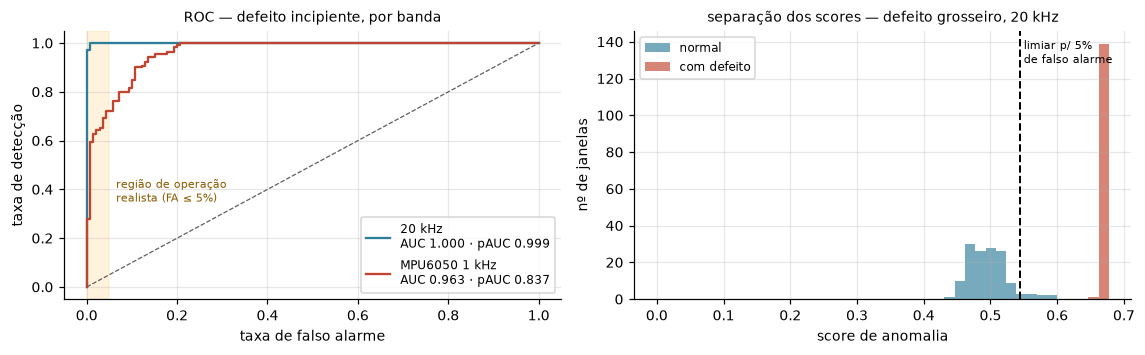

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3))
ax = axes[0]
for yy, ss, auc, pa, lab, c in [(y_ref, sc_ref, auc_ref, p10_ref, "20 kHz", C_OK),
                                (y_mpu, sc_mpu, auc_mpu, p10_mpu, "MPU6050 1 kHz", C_DEF)]:
    fpr, tpr, _ = roc_curve(yy, ss)
    ax.plot(fpr, tpr, lw=1.5, color=c, label=f"{lab}\nAUC {auc:.3f} · pAUC {pa:.3f}")
ax.plot([0,1],[0,1], ls="--", lw=0.8, color=C_REF)
ax.axvspan(0, 0.05, color="orange", alpha=0.13)
ax.text(0.065, 0.35, "região de operação\nrealista (FA ≤ 5%)", fontsize=7, color="#8a5a00")
ax.set_xlabel("taxa de falso alarme"); ax.set_ylabel("taxa de detecção")
ax.set_title("ROC — defeito incipiente, por banda", fontsize=9)
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
bins = np.linspace(min(scores.min(), 0), scores.max(), 45)
ax.hist(scores[yc==0], bins=bins, alpha=0.65, color=C_OK, label="normal")
ax.hist(scores[yc==1], bins=bins, alpha=0.65, color=C_DEF, label="com defeito")
lim = np.quantile(scores[yc==0], 0.95)
ax.axvline(lim, color="black", lw=1.3, ls="--")
ax.text(lim, ax.get_ylim()[1]*0.88, " limiar p/ 5%\n de falso alarme", fontsize=7.5)
ax.set_xlabel("score de anomalia"); ax.set_ylabel("nº de janelas")
ax.set_title("separação dos scores — defeito grosseiro, 20 kHz", fontsize=9)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

### Conclusão do item 7

- `contamination` é um parâmetro de **limiar**, não de qualidade. O default `"auto"`
  produziu **42% de falso alarme** neste cenário, contra 1,4% com `contamination=0.01`.
  A detecção foi de 100% em todos os casos: o que muda é apenas onde o corte é feito.
  O limiar deve sair de um conjunto de validação com taxa de falso alarme alvo — com 1%
  de alvo, o detector manteve 100% de detecção.
- No defeito incipiente, o AUC cai de 1,000 para 0,963 apenas por trocar a banda de
  aquisição — 3,7%, aparentemente modesto. Mas a **pAUC**, restrita à região de operação
  realista, cai de 0,999 para 0,837 (**16,2%**) com falso alarme de 10%, e de 0,998 para
  0,795 (**20,3%**) com 5%. A perda real é quatro a cinco vezes maior do que a AUC
  global sugere.
- Isso justifica a escolha de métrica: o DCASE2020 Task 2, benchmark do cenário idêntico
  ao nosso, adota pAUC precisamente porque a AUC global não caracteriza o ponto de
  operação. **Nenhum ajuste de modelo recupera informação que o sensor não capturou.**

## Síntese

| # | Questionamento | Resultado numérico | Situação |
|---|---|---|---|
| 1 | Banda do MPU6050 | contraste em BPFO cai de 413× para 20×; curtose deixa de separar (1,76 vs 1,77) | **confirmado, com ressalva** |
| 2 | Cadeia ISO 10816-3 | integração na frequência acerta (erro 0,003%); no tempo, erro de 73% a 716% | **confirmado** |
| 6 | Vazamento no split | 99,0% (aleatório) vs 63,2% ± 19,2% (por ensaio) | **confirmado** |
| 7 | Isolation Forest | `"auto"` → 42% de falso alarme; pAUC 0,999 → 0,837 pela banda | **confirmado** |

### O que fazer com isso

**Decisão de hardware (bloqueia o resto).** Duas evidências independentes apontam para
a mesma revisão do sensor: a perda de contraste em defeito de rolamento (item 1) e a
impossibilidade de cobrir a banda de 10–1000 Hz exigida pela ISO 10816-3 com Nyquist em
500 Hz (item 2). Se o MPU6050 for mantido por custo — decisão legítima —, o escopo
precisa declarar explicitamente que o Kaelix detecta desbalanceamento e desalinhamento,
não rolamento, e que a conformidade com a norma é parcial.

**Correções de firmware, independentes da decisão acima.** Configurar o DLPF do MPU6050
(sem isso a cadeia C é o que roda de fato) e implementar a integração na frequência com
banda ISO, reaproveitando a FFT já calculada.

**Correções de metodologia.** Refazer a validação com `GroupKFold` por ensaio e derivar
o limiar do Isolation Forest de um conjunto de validação com taxa de falso alarme alvo.

### Limitações

Os sinais são sintéticos e as conclusões valem para a *pipeline*, não para o desempenho
em campo. Os números de contraste e AUC dependem dos parâmetros da simulação —
amplitude do defeito, frequência de ressonância, nível de ruído — e devem ser lidos como
ordens de grandeza, não como previsão. As pendências que dependem de dado externo
continuam abertas: layout do MAFAULDA e do CWRU (pendência do projeto), texto oficial da
norma e classe real dos motores (item 3), e temperatura de carcaça medida (item 4).